In [1]:
from PIL import Image
import numpy as np
from skimage.color import rgb2lab


In [2]:
image = Image.open('Dataset/zoo.jpg').convert('RGB')

image_np = np.array(image).astype(np.float32)/255

lab_image = rgb2lab(image_np)

for i in range(3):
    print(f'Channel {i} has min: {lab_image[:,:,i].min():.2f} and max: {lab_image[:,:,i].max():.2f}')

    if i == 0:
        lab_image[:,:,i] = (lab_image[:,:, i] - 50) / 50
    else:
        lab_image[:,:,i] = lab_image[:,:, i] / 110
    
    print(f'Channel {i} has min: {lab_image[:,:,i].min():.2f} and max: {lab_image[:,:,i].max():.2f}')

Channel 0 has min: 0.20 and max: 96.90
Channel 0 has min: -1.00 and max: 0.94
Channel 1 has min: -54.50 and max: 63.48
Channel 1 has min: -0.50 and max: 0.58
Channel 2 has min: -7.23 and max: 78.45
Channel 2 has min: -0.07 and max: 0.71


# Why Lab color space instead of RGB?

If we predict RGB directly, the network has to output 3 correlated channels (Red, Green, Blue) from a single grayscale input — small errors in each channel compound, often producing muddy or desaturated results.
Lab color space separates lightness from color:

*   L (Lightness) — essentially is our grayscale input, values 0–100
*   a (green ↔ red) and b (blue ↔ yellow) — the actual color information

By converting training images to Lab, the task becomes: given L, predict a and b. The network only needs to learn 2 output channels instead of 3, and since L is fixed (it's literally the input), the model can never mess up brightness — it only has to get color right. This tends to produce cleaner, more accurate colorization than predicting RGB directly.

------

# Building the PyTorch Dataset 

In [3]:
from torch.utils.data import Dataset
import torch

In [4]:
class ColorizationDataset(Dataset):

    def __init__(self, image_paths):
        super().__init__()
        self.image_paths = image_paths # e.g. ['zoo.jpg', 'lion.jpg', 'tiger.jpg']

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        image = image.resize((256,256))

        image_np = np.array(image).astype(np.float32) / 255

        lab_img = rgb2lab(image_np)

        for i in range(3):
            if i == 0:
                lab_img[:,:,i] = (lab_img[:,:, i] - 50) / 50
            else:
                lab_img[:,:,i] = lab_img[:,:, i] / 110
        
        L = lab_img[:,:, 0]
        ab = lab_img[:,:, 1:]
        
        L = torch.tensor(L).unsqueeze(0) # (H, W) -> (1, H, W)
    
        ab = np.transpose(ab, (2,0,1))
        ab = torch.tensor(ab)
    
        return L, ab
        

## Test Time

In [5]:
import glob

image_paths = glob.glob('./Dataset/*.jpg')
print(f'image paths: {image_paths}')

dataset = ColorizationDataset(image_paths)
print(f'Dataset size: {len(dataset)}')

L,ab = dataset[0]

print(f'L shape: {L.shape}, dtype: {L.dtype}')
print(f'ab shape: {ab.shape}, dtype: {ab.dtype}')

image paths: ['./Dataset/image_1502.jpg', './Dataset/image_811.jpg', './Dataset/image_1264.jpg', './Dataset/image_1270.jpg', './Dataset/image_2779.jpg', './Dataset/image_805.jpg', './Dataset/image_1516.jpg', './Dataset/image_2037.jpg', './Dataset/image_1258.jpg', './Dataset/image_2989.jpg', './Dataset/image_193.jpg', './Dataset/image_2751.jpg', './Dataset/image_187.jpg', './Dataset/image_2745.jpg', './Dataset/image_2023.jpg', './Dataset/image_839.jpg', './Dataset/image_2976.jpg', './Dataset/image_178.jpg', './Dataset/image_2962.jpg', './Dataset/image_636.jpg', './Dataset/image_150.jpg', './Dataset/image_2792.jpg', './Dataset/image_144.jpg', './Dataset/image_2786.jpg', './Dataset/image_622.jpg', './Dataset/image_1066.jpg', './Dataset/image_3117.jpg', './Dataset/image_2209.jpg', './Dataset/image_1700.jpg', './Dataset/image_15.jpg', './Dataset/image_1714.jpg', './Dataset/image_3103.jpg', './Dataset/image_1072.jpg', './Dataset/image_2553.jpg', './Dataset/image_391.jpg', './Dataset/image_29

everything looks fine time to move on and collect images

--------------

# API Settings

In [7]:
import requests 
import os
from dotenv import load_dotenv

load_dotenv()
API = os.environ.get('PEXELS_API_KEY')

print(API is not None)

True


In [55]:
url = 'https://api.pexels.com/v1/search'

headers = {"Authorization": API}
queries = ['landscape', 'coffee', 'animals', 'art gallery', 'city', 'people', 'forest', 
           'beach', 'mountains', 'sunset', 'flowers', 'portrait', 'family', 'kitchen',
           'library', 'fruit', 'pets', 'bird', 'cat', 'dog', "rainbow", "colorful architecture", 
           "street art", "graffiti", "flower garden", "tropical flowers", "autumn leaves", 
           "festival", "fireworks", "carnival", "candy", "balloons", "neon lights",
           "tropical fish", "parrot", "stained glass", "spice market", "kites", 
           "textile fabric", "coral reef"] 

img_urls = []
i = 0

for query in queries:
    i+= 1
    params = {
        'query' : query,
        'per_page' : 80 # for this search term, give me 50 photos back. Max value: 80
    }

    response = requests.get(url, headers=headers, params=params)
    print(f"{query}: {response.status_code}", end = ' ')

    if i % 10 == 0:
        print('')
    
    data = response.json()
    photos = data['photos']

    for photo in photos:
        image_url = photo['src']['large']
        img_urls.append(image_url)


landscape: 200 coffee: 200 animals: 200 art gallery: 200 city: 200 people: 200 forest: 200 beach: 200 mountains: 200 sunset: 200 
flowers: 200 portrait: 200 family: 200 kitchen: 200 library: 200 fruit: 200 pets: 200 bird: 200 cat: 200 dog: 200 
rainbow: 200 colorful architecture: 200 street art: 200 graffiti: 200 flower garden: 200 tropical flowers: 200 autumn leaves: 200 festival: 200 fireworks: 200 carnival: 200 
candy: 200 balloons: 200 neon lights: 200 tropical fish: 200 parrot: 200 stained glass: 200 spice market: 200 kites: 200 textile fabric: 200 coral reef: 200 


In [56]:
from tqdm import tqdm

for i, img_url in enumerate(tqdm(img_urls)):
    response = requests.get(img_url)

    with open(f'./Dataset/image_{i}.jpg', 'wb') as f:
        f.write(response.content)

100%|██████████| 3198/3198 [14:57<00:00,  3.56it/s]


In [8]:
import shutil


dataset_dir = './Dataset'
bad_dir = './Dataset_bad'
os.makedirs(bad_dir, exist_ok=True)

bad_files = []

for filename in os.listdir(dataset_dir):
    filepath = os.path.join(dataset_dir, filename)
    try:
        img = Image.open(filepath)
        img.verify()
    except Exception as e:
        bad_files.append(filename)
        shutil.move(filepath, os.path.join(bad_dir, filename))
        print(f"Moved bad file: {filename} — {e}")

print(f"\nMoved {len(bad_files)} bad files to {bad_dir}")
print(f"Remaining good files: {len(os.listdir(dataset_dir))}")

shutil.rmtree(bad_dir)  # permanently deletes the whole Dataset_bad folder


Moved 0 bad files to ./Dataset_bad
Remaining good files: 3197


In [9]:
image_paths = glob.glob('./Dataset/*.jpg')

dataset = ColorizationDataset(image_paths)

-----

# U-Net Structure 

In [10]:
import torch
import torch.nn as nn

def conv_block(in_channels, out_channels):

    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size= 3, padding= 1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace = True),
        nn.Conv2d(out_channels, out_channels, kernel_size= 3, padding= 1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace= True)
    )

In [11]:
block = conv_block(1, 64)
dummy_input = torch.randn(1, 1, 256, 256)
output = block(dummy_input)

print(output.shape)

torch.Size([1, 64, 256, 256])


## Downsampling Step

In [12]:
class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = conv_block(in_channels, out_channels)
    
    def forward(self, x):
        x = self.pool(x)
        x = self.conv(x)

        return x

In [13]:
down = Down(64, 128)
dummy = torch.randn(1, 64, 256, 256)
out = down(dummy)
print(out.shape)

torch.Size([1, 128, 128, 128])


## Upsampling step

In [14]:
class Up(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size= 2, stride= 2)
        # output_size = (input_size - 1) * stride + kernel_size

        self.conv = conv_block(in_channels, out_channels)
        # in_channels here = concatenated size
    
    def forward(self, x, skip):
        x = self.up(x)
        x = torch.concat([skip, x], dim = 1) # dim1 = channel dimension, (batch, channel, width, height)
        x = self.conv(x)
    
        return x 

In [15]:
up = Up(256, 128)
dummy_x = torch.randn(1, 256, 32, 32)
dummy_skip = torch.randn(1, 128, 64, 64)

out = up(dummy_x, dummy_skip)
print(out.shape)

torch.Size([1, 128, 64, 64])


-------

# ColorizationUNet:

In [25]:
class ColorizationUNet(nn.Module):

    def __init__(self, start = 32):
        super().__init__()

        self.in_conv = conv_block(1, start)
        
        self.down1 = Down(start, start * 2)
        self.down2 = Down(start * 2, start * 4)
        self.down3 = Down(start * 4, start * 8)
        self.down4 = Down(start * 8, start * 16)

        self.up1 = Up(start * 16, start * 8)
        self.up2 = Up(start * 8,  start * 4)
        self.up3 = Up(start * 4,  start * 2)
        self.up4 = Up(start * 2,  start)

        self.out_conv = nn.Conv2d(start, 2, kernel_size= 1)

    
    def forward(self, x):
        skips = []

        x = self.in_conv(x)
        skips.append(x)

        x = self.down1(x)
        skips.append(x)

        x = self.down2(x)
        skips.append(x)

        x = self.down3(x)
        skips.append(x)

        x = self.down4(x)

        ########

        x = self.up1(x, skips[-1])
        x = self.up2(x, skips[-2])
        x = self.up3(x, skips[-3])
        x = self.up4(x, skips[-4])

        ########

        x = self.out_conv(x)
        x = torch.tanh(x)

        return x

In [17]:
model = ColorizationUNet()
dummy = torch.randn(1, 1, 256, 256)
out = model(dummy)

print(out.shape)

torch.Size([1, 2, 256, 256])


------

# Loss function & training loop

In [18]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

device

device(type='mps')

In [26]:
from torch.utils.data import DataLoader, random_split

image_paths = glob.glob('./Dataset/*.jpg')
dataset = ColorizationDataset(image_paths)

BATCH_SIZE = 8

val_size = int(len(dataset) * 0.1)
train_size = len(dataset) - val_size

train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size= BATCH_SIZE, shuffle= True)
val_loader = DataLoader(val_set, batch_size= BATCH_SIZE, shuffle= False)

model = ColorizationUNet(start = 64)
model = model.to(device)
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(model.parameters(), lr = 2e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode = 'min', factor = 0.5, patience= 10
)

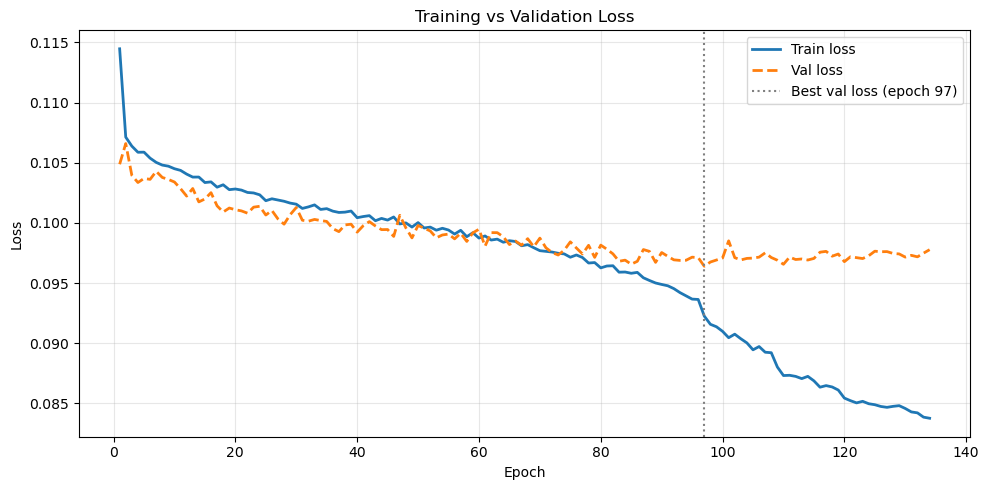

KeyboardInterrupt: 

In [27]:
from myLibrary import plot_losses, show_predictions

EPOCH = 500
train_losses = []
val_losses = []
best_val_loss = float('inf')

os.makedirs('checkpoints', exist_ok=True)

for epoch in range(EPOCH):
    model.train()
    total_loss = 0
    val_total_loss = 0

    for L_batch, ab_batch in train_loader:

        L_batch, ab_batch = L_batch.to(device), ab_batch.to(device)

        optimizer.zero_grad()
        pred = model(L_batch)

        loss = criterion(ab_batch, pred)
        loss.backward()

        optimizer.step()
        total_loss += loss.item()



    model.eval()
    with torch.no_grad():
        for L_batch, ab_batch in val_loader:

            L_batch, ab_batch = L_batch.to(device), ab_batch.to(device)

            pred = model(L_batch)
            loss = criterion(pred, ab_batch)

            val_total_loss += loss.item()

    scheduler.step(val_total_loss/len(val_loader))

    train_losses.append(total_loss/ len(train_loader))
    val_losses.append(val_total_loss / len(val_loader))

    plot_losses(train_losses, val_losses)

    if (epoch + 1) % 5 == 0:          # show sample predictions every 5 epochs
        show_predictions(model, val_loader, device, n=4)

        # Save best model
    if (val_total_loss / len(val_loader)) < best_val_loss:
        best_val_loss = (val_total_loss / len(val_loader))
        torch.save(model.state_dict(), 'checkpoints/best_model.pt')
        print(f"  -> New best model saved (val loss: {best_val_loss:.4f})")

    # Periodic checkpoint, regardless of whether it's the best (safety net against crashes)
    if (epoch + 1) % 20 == 0:
        torch.save(model.state_dict(), f'checkpoints/epoch_{epoch+1}.pt')

In [54]:
import torch
import numpy as np
from PIL import Image
from skimage.color import rgb2lab, lab2rgb
import matplotlib.pyplot as plt

def colorize_image(model, image_path, device, image_size=256):
    model.eval()

    image = Image.open(image_path).convert('RGB')
    image = image.resize((image_size, image_size))
    image_np = np.array(image).astype(np.float32) / 255.0

    lab = rgb2lab(image_np)
    L = lab[:, :, 0]

    # Normalize L the same way as training
    L_norm = (L / 50.0) - 1.0
    L_tensor = torch.tensor(L_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)
    L_tensor = L_tensor.to(device)

    with torch.no_grad():
        pred_ab = model(L_tensor)

    pred_ab = pred_ab.squeeze(0).cpu().numpy().transpose(1, 2, 0) * 110  # un-normalize

    lab_pred = np.concatenate([L[:, :, None], pred_ab], axis=2)
    rgb_pred = lab2rgb(lab_pred)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(L, cmap='gray')
    axes[0].set_title("Grayscale Input")
    axes[1].imshow(rgb_pred)
    axes[1].set_title("Colorized")
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [58]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = ColorizationUNet(start = 64)  # must match the architecture you trained (same channel sizes!)
model.load_state_dict(torch.load('checkpoints/best_model.pt', map_location=device))
model = model.to(device)
model.eval()
print()

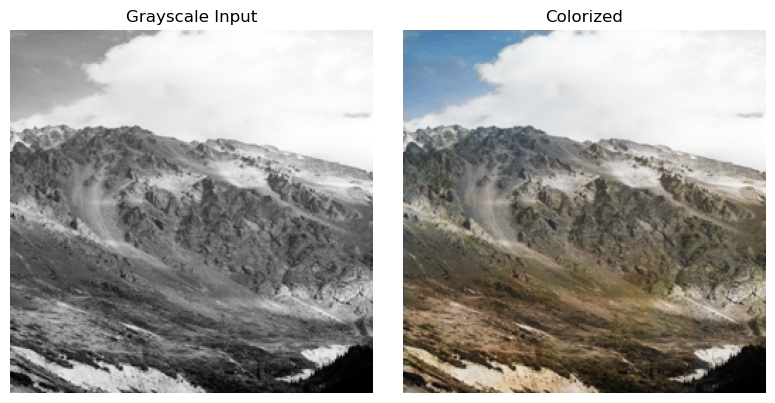

In [59]:
colorize_image(model, 'Dataset/image_640.jpg', device)

------

# Brownish Pic Problem & Adding a new Loss

So nothing much changed, and the pictures are still brownish?!

I would like to add another loss now to train my network and see whether we can escape this issue.

What Weighted Color Loss does

Standard L1 loss treats every pixel equally — a vivid red flower and a gray sidewalk both contribute the same amount to the loss if the model gets them equally "wrong" in absolute terms. This is part of why colorization models tend to predict safe, muted, brownish colors: playing it safe minimizes average error across all pixels, including the many desaturated ones in typical photos.
Weighted Color Loss changes this by weighting each pixel's loss based on how saturated the true color actually is:

*   Compute the chroma (color intensity) of the ground truth pixel: chroma = sqrt(a² + b²) — near 0 for grays/browns, larger for vivid, saturated colors.

*   Use that chroma as a multiplier on the pixel's loss — so getting a vivid red or blue pixel wrong is penalized more heavily than getting a gray pixel wrong.

*   A small base_weight ensures desaturated pixels still count for something — they're just no longer allowed to dominate the average.

The intended effect: the model is pushed to prioritize accuracy on colorful regions specifically, rather than hedging everywhere with a "safe average" prediction — nudging output away from the desaturated/brownish look and toward bolder, more saturated colors where the ground truth actually has them.

In [61]:
class WeightedColorLoss(nn.Module):
    def __init__(self, base_weight=1.0):
        """
        base_weight: minimum weight every pixel gets, even if fully desaturated.
                     Prevents desaturated pixels from being weighted to zero
                     (they still matter, just less).
        """
        super().__init__()
        self.base_weight = base_weight

    def forward(self, pred_ab, target_ab):
        # Chroma of the ground truth, per pixel: sqrt(a^2 + b^2)
        chroma = torch.sqrt(target_ab[:, 0:1] ** 2 + target_ab[:, 1:2] ** 2 + 1e-8)

        # Normalize chroma to a reasonable weight range, then add the base
        weight = self.base_weight + chroma  # shape: (B, 1, H, W)

        l1 = torch.abs(pred_ab - target_ab)          # (B, 2, H, W)
        weighted_l1 = l1 * weight                      # broadcasts weight across both a,b channels

        return weighted_l1.mean()

In [68]:
image_paths = glob.glob('./Dataset/*.jpg')
dataset = ColorizationDataset(image_paths)

BATCH_SIZE = 8

val_size = int(len(dataset) * 0.1)
train_size = len(dataset) - val_size

train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size= BATCH_SIZE, shuffle= True)
val_loader = DataLoader(val_set, batch_size= BATCH_SIZE, shuffle= False)

model = ColorizationUNet(start = 64)
model = model.to(device)

l1_criterion = nn.L1Loss()
weighted_criterion = WeightedColorLoss(base_weight= 1.0)


optimizer = torch.optim.Adam(model.parameters(), lr = 0.004)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode = 'min', factor = 0.5, patience= 10
)

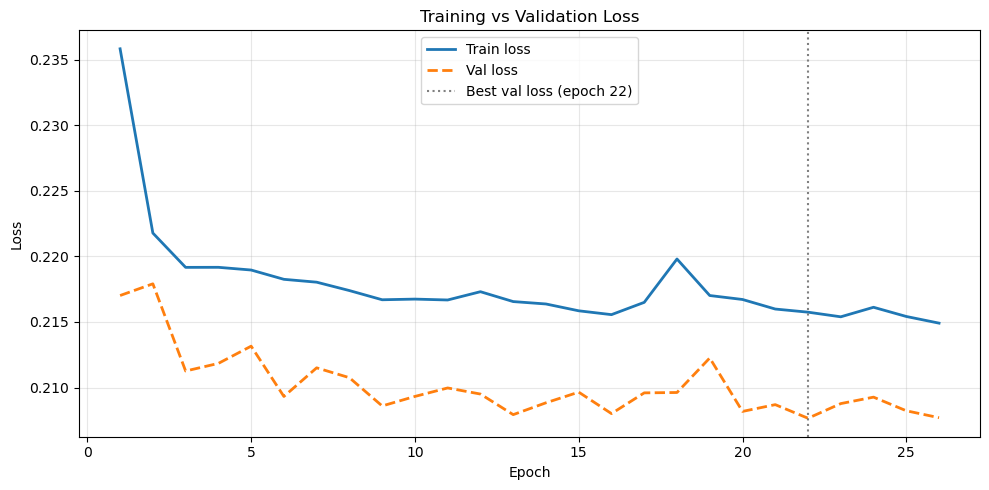

No improvement for 20 epochs — stopping early at epoch 26.


In [69]:
from myLibrary import plot_losses, show_predictions

EPOCH = 500
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 20          # how many epochs to tolerate with no improvement
epochs_without_improvement = 0

os.makedirs('checkpoints/withExtraLoss', exist_ok=True)

for epoch in range(EPOCH):
    model.train()
    total_loss = 0
    val_total_loss = 0

    for L_batch, ab_batch in train_loader:

        L_batch, ab_batch = L_batch.to(device), ab_batch.to(device)

        optimizer.zero_grad()
        pred = model(L_batch)

        loss = l1_criterion(ab_batch,pred) + weighted_criterion(ab_batch, pred)
        loss.backward()

        optimizer.step()
        total_loss += loss.item()



    model.eval()
    with torch.no_grad():
        for L_batch, ab_batch in val_loader:

            L_batch, ab_batch = L_batch.to(device), ab_batch.to(device)

            pred = model(L_batch)
            loss = l1_criterion(ab_batch,pred) + weighted_criterion(ab_batch, pred)

            val_total_loss += loss.item()

    scheduler.step(val_total_loss/len(val_loader))

    train_losses.append(total_loss/ len(train_loader))
    val_losses.append(val_total_loss / len(val_loader))

    plot_losses(train_losses, val_losses)

    if (epoch + 1) % 5 == 0:          # show sample predictions every 5 epochs
        show_predictions(model, val_loader, device, n=4)

        # Save best model
    if (val_total_loss / len(val_loader)) < best_val_loss:
        best_val_loss = (val_total_loss / len(val_loader))
        torch.save(model.state_dict(), 'checkpoints/withExtraLoss/best_model.pt')
        print(f"  -> New best model saved (val loss: {best_val_loss:.4f})")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"No improvement for {patience} epochs — stopping early at epoch {epoch+1}.")
        break

    # Periodic checkpoint, regardless of whether it's the best (safety net against crashes)
    if (epoch + 1) % 20 == 0:
        torch.save(model.state_dict(), f'checkpoints/withExtraLoss/epoch_{epoch+1}.pt')